In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# Configurações visuais
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Semente para reprodutibilidade
np.random.seed(42)

In [5]:
# Conceitos Fundamentais

# Espaço Amostral e Eventos
# Criando o Espaço Amostral (Todas combinações possíveis de 2 dados)
dado = [1, 2, 3, 4, 5, 6]
espaco_amostral = [(d1, d2) for d1 in dado for d2 in dado]

# Definindo o Evento: Soma > 7
evento_sucesso = [lancamento for lancamento in espaco_amostral if sum(lancamento) > 7]

# Cálculo da Probabilidade: P(E) = Casos Favoraveis / Casos Possíveis
probabilidade = len(evento_sucesso) / len(espaco_amostral)

print(f"\nTamanho do Espaço Amostral: {len(espaco_amostral)}")
print(f"\nOcorrência do evento (Soma > 7): {len(evento_sucesso)}")
print(f"\nProbabilidade calculada: {probabilidade:.2%}")


Tamanho do Espaço Amostral: 36

Ocorrência do evento (Soma > 7): 15

Probabilidade calculada: 41.67%


In [6]:
# Teorema de Bayes

# Priors (Probabilidade e priori)
p_doenca = 0.01
p_nao_doenca = 1 - p_doenca

# Likelihoods (Probabilidade condicionais do teste)
p_pos_dado_doenca = 0.99 # Verdadeiro Positivo
p_pos_dado_nao_doenca = 0.05 # Falso Positivo

# Probabilidade Total de dar Positivo (P(B))
p_positivo = (p_pos_dado_doenca * p_doenca) + (p_pos_dado_nao_doenca * p_nao_doenca)

# Aplicação do Teorema de Bayes
p_doenca_dado_positivo = (p_pos_dado_doenca * p_doenca) / p_positivo

print(f"\nProbabilidade de ter a doença dado teste positivo: {p_doenca_dado_positivo:.2f}")
print(f"\nInsight: Mesmo com teste 99% preciso, a chance é baixa devido à raridade da doença.")


Probabilidade de ter a doença dado teste positivo: 0.17

Insight: Mesmo com teste 99% preciso, a chance é baixa devido à raridade da doença.



Probabilidade de exatamente 2 vendas em 10 visitas: 23.30%


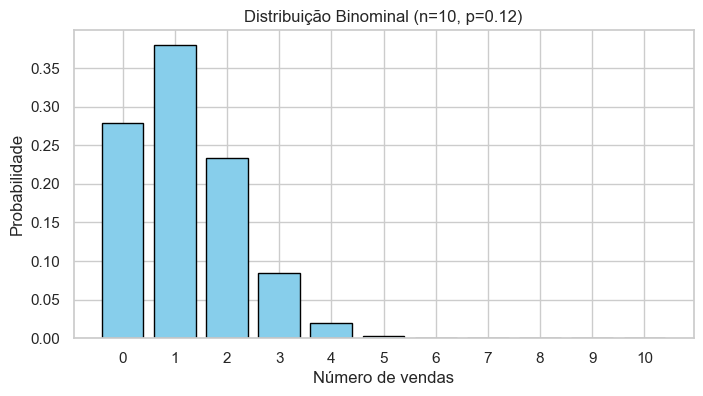

In [9]:
# Distribuição de Probabilidades Discretas

# Bernoulli e Binomial (Sucesso ou Fracasso)
n = 10 # Número de tentativas (clientes)
p = 0.12 # Probabilidade de sucesso (compra)
k = 2 # Número de sucessos desejados

# Cálculando P(X=k) usando a Função Massa de Probabilidade (PMF)
prob_2_vendas = stats.binom.pmf(k, n, p)

print(f"\nProbabilidade de exatamente 2 vendas em 10 visitas: {prob_2_vendas:.2%}")

# Visualização da distribuição completa
x = np.arange(0, n+1) # Possibilidades: 0 a 10 vendas
probs = stats.binom.pmf(x, n, p)

plt.figure(figsize=(8, 4))
plt.bar(x, probs, color='skyblue', edgecolor='black')
plt.title(f'Distribuição Binominal (n={n}, p={p})')
plt.xlabel('Número de vendas')
plt.ylabel('Probabilidade')
plt.xticks(x)
plt.show()


Risco de sobrecarga (>8 req/s): 6.81%


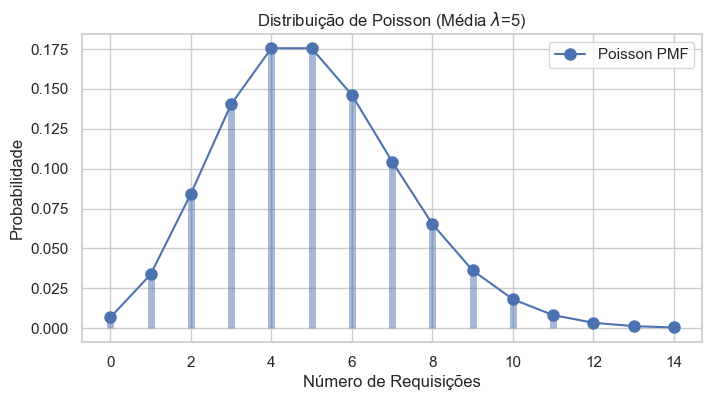

In [13]:
# distribuição de Poison

mu = 5 # Taxa média (lambda)

# Probabilidade acumulada de receber ATÉ 8 (cdf)
prob_ate_8 = stats.poisson.cdf(8, mu)

# Probabilidade de receber MAIS de 8 (1 - acumulada)
prob_mais_que_8 = 1 - prob_ate_8

print(f"\nRisco de sobrecarga (>8 req/s): {prob_mais_que_8:.2%}")

# Visualização
x = np.arange(0, 15)
plt.figure(figsize=(8, 4))
plt.plot(x, stats.poisson.pmf(x, mu), 'bo-', ms=8, label='Poisson PMF')
plt.vlines(x, 0, stats.poisson.pmf(x, mu), colors='b', lw=5, alpha=0.5)
plt.title(f'Distribuição de Poisson (Média $\\lambda$={mu})')
plt.xlabel('Número de Requisições')
plt.ylabel('Probabilidade')
plt.legend()
plt.show()

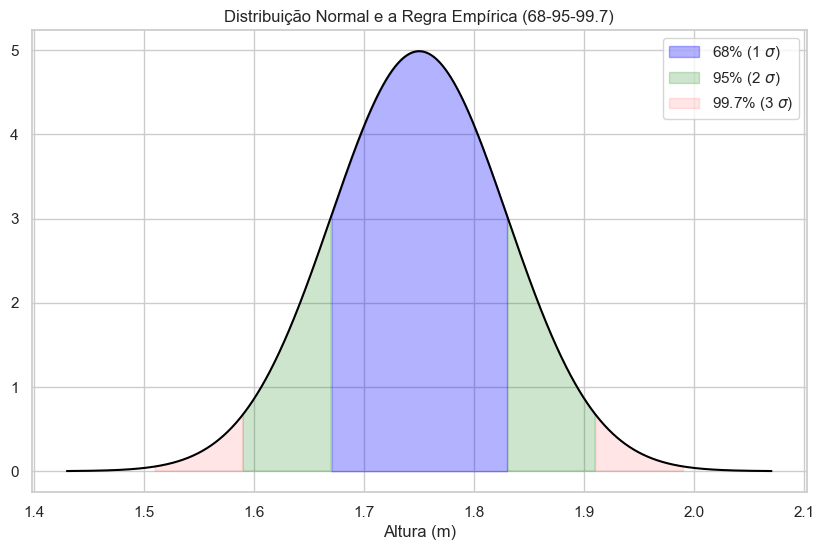

In [15]:
# Distribuições de Probabilidade Contínuas

# Distribuição Normal (Gaussiana) e a Regra Empírica
mu = 1.75
sigma = 0.08

# Gerando dados para o eixo X
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = stats.norm.pdf(x, mu, sigma) # PDF - Função Densidade de Probabilidade

plt.figure(figsize=(10, 6))
plt.plot(x, y, color='black')

# Colorindo as áreas da Regra Empírica
# 1 Desvio Padrão (68%)
plt.fill_between(x, y, where=((x >= mu-sigma) & (x <= mu+sigma)), color='blue', alpha=0.3, label='68% (1 $\\sigma$)')
# 2 Desvios Padrão (95%)
plt.fill_between(x, y, where=((x >= mu-2*sigma) & (x < mu-sigma)) | ((x > mu+sigma) & (x <= mu+2*sigma)), color='green', alpha=0.2, label='95% (2 $\\sigma$)')
# 3 Desvios Padrão (99.7%)
plt.fill_between(x, y, where=((x >= mu-3*sigma) & (x < mu-2*sigma)) | ((x > mu+2*sigma) & (x <= mu+3*sigma)), color='red', alpha=0.1, label='99.7% (3 $\\sigma$)')

plt.title('Distribuição Normal e a Regra Empírica (68-95-99.7)')
plt.xlabel('Altura (m)')
plt.legend()
plt.show()

In [16]:
# Z-Score (Padronização)

# Dados João
x_joao = 1.95
mu_h = 1.75
sigma_h = 0.08

# Dados Maria
x_maria = 135
mu_qi = 100
sigma_qi = 15

# Cálculo Manual do Z-Score
z_joao = (x_joao - mu_h) / sigma_h
z_maria = (x_maria - mu_qi) / sigma_qi

print(f"Z-Score João: {z_joao:.2f}")
print(f"Z-Score Maria: {z_maria:.2f}")

if z_joao > z_maria:
    print("João é estatisticamente mais raro (mais extremo) que Maria.")
else:
    print("Maria é estatisticamente mais rara (mais extrema) que João.")

# Usando Scipy para calcular a probabilidade de encontrar alguém maior que o João
prob_maior_joao = 1 - stats.norm.cdf(z_joao) # 1 - área acumulada até o Z dele
print(f"Probabilidade de encontrar alguém mais alto que João: {prob_maior_joao:.4%}")

Z-Score João: 2.50
Z-Score Maria: 2.33
João é estatisticamente mais raro (mais extremo) que Maria.
Probabilidade de encontrar alguém mais alto que João: 0.6210%
